# Why Weight Initialization is important

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

- Download dataset from here
 https://www.kaggle.com/datasets/hafeezabro/ushape

In [62]:
#Load the dataset
df = pd.read_csv('ushape.csv')
df = df.rename(columns={'3.159499363321345566e-02': 'X', '9.869877579082642072e-01': 'Y',
                        '0.000000000000000000e+00': "class"})

In [63]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


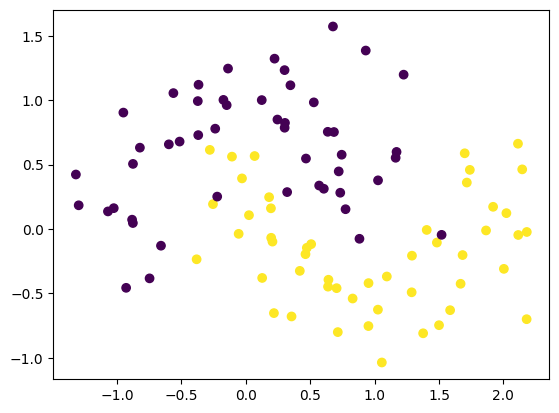

In [64]:
plt.scatter(df['X'], df['Y'], c=df['class'])

In [65]:
# Preprocessing the Data
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [66]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

# 1. By Taking Zero as a value for Weight Initialization

#### Check Relu, Tanh and Sigmoid Activation Function one by one

In [67]:
model = Sequential()

# model.add(Dense(2, activation='relu', input_dim=2))
# model.add(Dense(2, activation='tanh', input_dim=2))
model.add(Dense(10, activation='sigmoid', input_dim=2)) # adding 10 node in hidden layer
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.get_weights() # defaults weights and biases

[array([[-0.29585132, -0.49096593, -0.21834478, -0.21046299,  0.6107424 ,
         -0.15746146,  0.12846547,  0.5848742 ,  0.09884208, -0.26288489],
        [-0.36936772, -0.40965068, -0.27773052,  0.30208653,  0.3949898 ,
         -0.6042712 , -0.07852346,  0.47674662, -0.21742141,  0.22015357]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.72499627],
        [ 0.54105955],
        [ 0.09591001],
        [ 0.47385746],
        [ 0.53719765],
        [-0.02424073],
        [-0.07222694],
        [ 0.56678313],
        [ 0.70164233],
        [ 0.4001841 ]], dtype=float32),
 array([0.], dtype=float32)]

In [69]:
# Fetch initial weights
initial_weights = model.get_weights()

In [70]:
# Set all weights and biases to zero
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [71]:
# Apply zero-initialized weights to the model
model.set_weights(initial_weights)

In [72]:
# Verify the weights
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [73]:
# Compile the model with binary crossentropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [74]:
# Train the model
history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=0)

In [75]:
model.get_weights()

[array([[ 0.40096584,  0.40096584,  0.40096584,  0.40096584,  0.40096584,
          0.40096584,  0.40096584,  0.40096584,  0.40096584,  0.40096584],
        [-0.43459108, -0.43459108, -0.43459108, -0.43459108, -0.43459108,
         -0.43459108, -0.43459108, -0.43459108, -0.43459108, -0.43459108]],
       dtype=float32),
 array([-0.11812869, -0.11812869, -0.11812869, -0.11812869, -0.11812868,
        -0.11812868, -0.11812868, -0.11812868, -0.11812868, -0.11812868],
       dtype=float32),
 array([[0.0538617],
        [0.0538617],
        [0.0538617],
        [0.0538617],
        [0.0538617],
        [0.0538617],
        [0.0538617],
        [0.0538617],
        [0.0538617],
        [0.0538617]], dtype=float32),
 array([-0.05556904], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

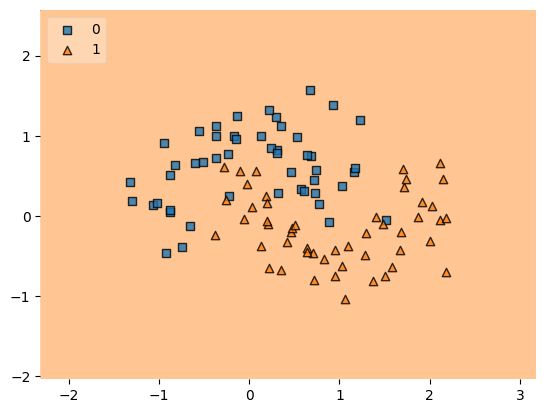

In [76]:
# Plot the decision boundary after training
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)

# 2. By Taking Non-Zero Constant value for Weight Initialization

In [77]:
model = Sequential()

# model.add(Dense(2, activation='relu', input_dim=2))
# model.add(Dense(2, activation='tanh', input_dim=2))
model.add(Dense(10, activation='sigmoid', input_dim=2)) # adding 10 node in hidden layer
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
model.get_weights() # defaults weights and biases

[array([[-0.5304083 , -0.36762604,  0.47130054, -0.68833977, -0.24359277,
          0.02195531,  0.4995436 ,  0.16289473,  0.5940251 ,  0.03146547],
        [-0.48308396, -0.22823495,  0.17523175, -0.58247936, -0.67991227,
         -0.5533714 ,  0.33620697, -0.5950029 ,  0.3444336 ,  0.6117571 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.55534536],
        [ 0.12204492],
        [-0.3799425 ],
        [-0.40183446],
        [ 0.573785  ],
        [-0.7252081 ],
        [-0.04046792],
        [ 0.08888888],
        [-0.07077914],
        [ 0.49250215]], dtype=float32),
 array([0.], dtype=float32)]

In [79]:
# Fetch initial weights
initial_weights = model.get_weights()

In [80]:
# Set all weights and biases to a Non-Zero Constant value
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [81]:
# Apply constant-initialization weights to the model
model.set_weights(initial_weights)

In [82]:
# Verify the weights
model.get_weights()
# Compile the model with binary crossentropy loss and Adam optimizer

[array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [83]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train the model
history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=0)

In [84]:
model.get_weights()

[array([[0.4439931, 0.4439931, 0.4439931, 0.4439931, 0.4439931, 0.4439931,
         0.4439931, 0.4439931, 0.4439931, 0.4439931],
        [0.2462941, 0.2462941, 0.2462941, 0.2462941, 0.2462941, 0.2462941,
         0.2462941, 0.2462941, 0.2462941, 0.2462941]], dtype=float32),
 array([0.25681755, 0.25681755, 0.25681755, 0.25681755, 0.25681755,
        0.25681755, 0.25681755, 0.25681755, 0.25681755, 0.25681755],
       dtype=float32),
 array([[0.23134312],
        [0.23134312],
        [0.23134312],
        [0.23134312],
        [0.23134312],
        [0.23134312],
        [0.23134312],
        [0.23134312],
        [0.23134312],
        [0.23134312]], dtype=float32),
 array([0.22286001], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


<Axes: >

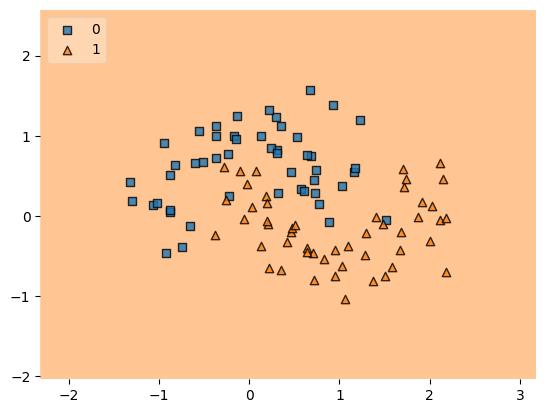

In [85]:
# Plot the decision boundary after training
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)

# 3. By Taking Random Value for Weight Initialization

## a. Small Random Values
- In Tanh Vanishing Gradient Problem  
- In Sigmoid Vanishing Gradient Problem only when we take deep Neural Networks
- In Relu it gives very small values

In [86]:
#Deep Neural Network
model = Sequential()

# Tanh
# model.add(Dense(2, activation='tanh', input_dim=2))
# model.add(Dense(2, activation='tanh'))
# model.add(Dense(2, activation='tanh'))
# model.add(Dense(2, activation='tanh'))
# model.add(Dense(1, activation='sigmoid'))

# model.add(Dense(2, activation='sigmoid', input_dim=2))
# model.add(Dense(2, activation='sigmoid'))
# model.add(Dense(2, activation='sigmoid'))
# model.add(Dense(2, activation='sigmoid'))
# model.add(Dense(1, activation='sigmoid'))

model.add(Dense(2, activation='relu', input_dim=2))
model.add(Dense(2, activation='relu'))
model.add(Dense(2, activation='relu'))
model.add(Dense(2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [87]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [88]:
model.get_weights() # defaults weights and biases

[array([[-0.71638733,  1.1709453 ],
        [ 1.0504338 , -0.28951174]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.30777323, -0.5621221 ],
        [-0.7826849 , -0.07167602]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.80717194,  0.09970987],
        [-0.4917333 , -0.81484455]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.54674417,  0.6285777 ],
        [ 0.01994777,  0.1511712 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.0644213],
        [-1.346148 ]], dtype=float32),
 array([0.], dtype=float32)]

In [89]:
# Fetch initial weights
initial_weights = model.get_weights()

In [90]:
# Set all weights to small random values and biases to zero
initial_weights[0] = np.random.randn(model.get_weights()[0].shape[0], model.get_weights()[0].shape[1])*0.01
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(model.get_weights()[2].shape[0], model.get_weights()[2].shape[1])*0.01
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(model.get_weights()[4].shape[0], model.get_weights()[4].shape[1])*0.01
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(model.get_weights()[6].shape[0], model.get_weights()[6].shape[1])*0.01
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(model.get_weights()[8].shape[0], model.get_weights()[8].shape[1])*0.01
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [91]:
# Apply Random-initialization weights and zero bias values
model.set_weights(initial_weights)

In [92]:
# Verify the weights
model.get_weights()

[array([[ 0.00242816,  0.01206243],
        [ 0.00182162, -0.01482249]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.00708413, -0.00675593],
        [-0.00122493, -0.01216527]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.00478306,  0.0104938 ],
        [ 0.02162174, -0.01282235]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.00747896,  0.01335929],
        [-0.00775994,  0.00594642]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.0179843 ],
        [0.01776505]], dtype=float32),
 array([0.], dtype=float32)]

In [93]:
# Compile the model with binary crossentropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Train the model
history = model.fit(X, y, epochs=100, validation_split=0.2, verbose=0)

In [94]:
model.get_weights()

[array([[ 0.00242452,  0.01206275],
        [ 0.00181787, -0.01482238]], dtype=float32),
 array([-4.2246147e-06,  3.2487139e-07], dtype=float32),
 array([[ 0.00708192, -0.00675593],
        [-0.00122678, -0.01216527]], dtype=float32),
 array([-0.00054283,  0.        ], dtype=float32),
 array([[ 0.00478164,  0.01049318],
        [ 0.02162174, -0.01282235]], dtype=float32),
 array([-0.00548374, -0.00494788], dtype=float32),
 array([[ 0.00747896,  0.01335878],
        [-0.00775994,  0.00594531]], dtype=float32),
 array([ 0.        , -0.00599784], dtype=float32),
 array([[0.0179843],
        [0.0177643]], dtype=float32),
 array([0.00309635], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

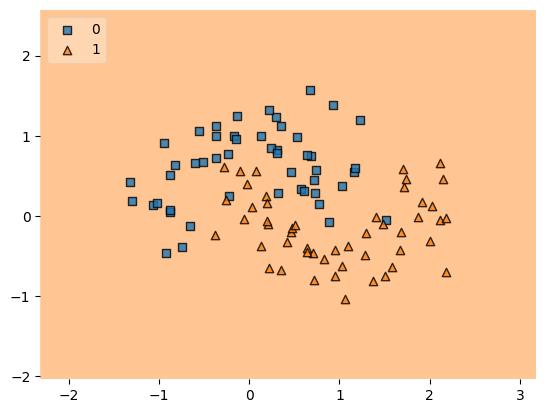

In [95]:
# Plot the decision boundary after training
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)

## b. Large Random Values
- Saturation values for Sigmoid and Tanh
- Non-Saturation values for Relu bcz it only takes +ve values so will gives unstable gradient becouse of large valus of activation
- Slow Training
- Vanishing Gradient Problem

# 4. How to give the best Weights and Bias Initialization values

- (a) Using xavier or Glorat Normal Initialization = sqrt(1/fan_in) apply on Tanh only, here   fan_in = no. of inputs in previous layer coming to this node

In [98]:
model = Sequential()

# Tanh
model.add(Dense(10, activation='tanh', kernel_initializer='glorot_normal', input_dim=2))
model.add(Dense(10, activation='tanh', kernel_initializer='glorot_normal',))
model.add(Dense(10, activation='tanh', kernel_initializer='glorot_normal',))
model.add(Dense(10, activation='tanh', kernel_initializer='glorot_normal',))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
model.get_weights() # defaults weights and biases

[array([[-0.11590728,  0.33574748, -0.5072878 , -0.18629092,  0.49588206,
         -0.24725637, -0.60776955,  0.24215607, -0.18696618,  0.19775939],
        [ 0.03254302, -0.22541283,  0.11395407, -0.8234669 ,  0.19409147,
         -0.20546018,  0.22018917,  0.0657059 ,  0.48014355, -0.28283852]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.25120577, -0.7127713 , -0.47213063, -0.21776888, -0.11056293,
          0.03499676, -0.19646744,  0.05590627, -0.23722242,  0.09265339],
        [-0.508849  , -0.47233748, -0.26841825,  0.466886  ,  0.07007643,
          0.17917421,  0.18903658,  0.66500515,  0.15208328,  0.08987791],
        [-0.02117115, -0.00400866, -0.24256201,  0.06778446,  0.20715138,
          0.02457014,  0.4350258 , -0.28346676, -0.0473619 ,  0.09501663],
        [ 0.5405805 , -0.1820389 ,  0.0752845 ,  0.6976163 ,  0.2106959 ,
         -0.01982666, -0.19519909, -0.27904227, -0.47628218, -0.22760992],
        [-0.04982

In [100]:
# Fetch initial weights
initial_weights = model.get_weights()

In [101]:
# xavier or Glorat Normal Initialization
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [102]:
model.set_weights(initial_weights)

In [103]:
# Verify the weights
model.get_weights()

[array([[-0.6942422 ,  0.29496738,  0.43537453, -0.41298023, -1.1331911 ,
         -1.7456417 ,  0.24568242, -0.25136298,  0.91382486, -0.02300804],
        [ 0.4484496 , -0.0492913 ,  0.63440603,  0.7492853 ,  0.34096804,
          1.0752232 , -0.11092279, -0.44265458, -0.2853441 ,  0.90442264]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.1558052 , -0.6298252 , -0.03423607, -0.00871153,  0.37720934,
         -0.49393958,  0.46882203, -0.33986977, -0.30795625,  0.08984374],
        [ 0.33132592, -0.10245993,  0.12220111,  0.27822655, -0.11821291,
         -0.14405672, -0.04268584,  0.08685024, -0.16926299,  0.1311003 ],
        [-0.12259348,  0.4289777 ,  0.5826852 , -0.64751846, -0.15513633,
          0.265244  , -0.42655638, -0.54112756,  0.32283527,  0.92064023],
        [-0.46509764, -0.07839563, -0.23371279, -0.5226376 , -0.02516641,
          0.19735745,  0.29056144, -0.26524314, -0.06959423, -0.3021236 ],
        [-0.18605

In [104]:
# Compile the model with binary crossentropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [105]:
# Train the model
history = model.fit(X, y, epochs=200, validation_split=0.2, verbose=0)

In [106]:
model.get_weights()

[array([[-0.5562169 ,  0.31409273,  0.8489229 , -0.43611658, -1.524485  ,
         -2.0681694 ,  0.39776844, -0.37860924,  0.7978064 ,  0.0394577 ],
        [ 0.5004001 , -0.07419871,  0.666526  ,  0.6901472 ,  0.21504316,
          1.003627  , -0.10248101, -0.6619981 , -0.32743025,  0.82556117]],
       dtype=float32),
 array([ 0.0811552 , -0.03919501,  0.26379254,  0.06620803,  0.29638636,
         0.40506864,  0.08363596, -0.08752292,  0.05985346,  0.12192515],
       dtype=float32),
 array([[-0.18689059, -0.6975767 , -0.01476269, -0.02933349,  0.44515768,
         -0.6015842 ,  0.4373581 , -0.39397773, -0.36000976, -0.04768784],
        [ 0.35076374, -0.00916035,  0.12233172,  0.31520557, -0.20257767,
         -0.01961461, -0.0569779 ,  0.14786936, -0.12519476,  0.34178466],
        [-0.18808895,  0.39682984,  0.5420892 , -0.6550424 , -0.13307594,
          0.19664109, -0.5832455 , -0.55175024,  0.32998636,  1.0819381 ],
        [-0.53893864, -0.14576507, -0.29240918, -0.58428854, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


<Axes: >

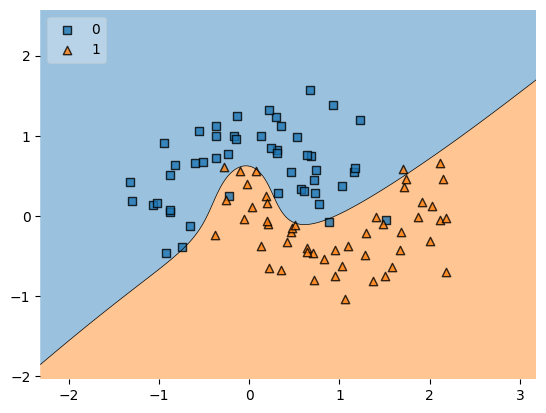

In [107]:
# Plot the decision boundary after training
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)

- (b) By Using He-Normal with relu activation function, = sqrt(2/fan_in)

In [108]:
model = Sequential()

# he_normal or he-uniform with Relu
model.add(Dense(10, activation='relu', kernel_initializer='he_normal', input_dim=2))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_46 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
model.get_weights() # defaults weights and biases

[array([[-0.12505597, -0.62177604, -2.0680318 , -1.0635544 ,  0.6568969 ,
         -0.5879709 , -1.2365962 ,  0.8813962 ,  0.86803126,  0.63251233],
        [ 0.32168004, -0.38910177, -0.9772421 , -1.8559734 ,  0.7430996 ,
          0.9254688 , -0.28127828,  1.8844268 ,  0.4030289 ,  0.4840159 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-2.9578993e-01, -5.2458936e-01, -1.1922050e-01,  1.5429519e-01,
          6.0131562e-01,  2.8917050e-01, -3.7130126e-01, -5.2216494e-01,
          1.6576019e-01,  7.0549869e-03],
        [ 4.5275295e-01,  1.7260778e-01,  4.8705935e-01,  2.1027257e-01,
         -6.9837582e-01,  2.5327909e-01,  1.4167373e-01, -4.4310984e-01,
         -8.4058982e-01,  7.0626289e-04],
        [ 6.2003726e-01,  3.6803508e-01,  4.3726641e-01,  3.6126468e-01,
          1.2392906e-01, -6.3783169e-01,  1.7347645e-02,  6.5971427e-02,
         -4.1077620e-01, -4.0170822e-01],
        [-6.4925998e-01,  3.3077139e-01,  2.04787

In [110]:
# Fetch initial weights
initial_weights = model.get_weights()

In [111]:
# He_Normal Initialization
initial_weights[0] = np.random.randn(2,10)*np.sqrt(2/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(2/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [112]:
model.set_weights(initial_weights)

In [113]:
# Verify the weights
model.get_weights()

[array([[ 0.81870514,  0.68201464,  1.9879521 ,  0.67246795,  0.43414977,
         -0.08083984,  1.75514   ,  0.81914467,  0.44810554, -0.70640826],
        [-1.4112481 , -0.50381625, -1.3365752 , -1.2000481 , -1.2091837 ,
          2.6932685 ,  1.2052963 , -0.2595159 ,  2.8665802 ,  0.44237146]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.17948976, -0.44510722,  0.8351192 ,  0.6835734 , -0.5084589 ,
         -0.06295893,  0.37556654, -0.22690813, -0.6779158 , -0.06528742],
        [ 0.05786203, -0.18799229, -0.25845695, -0.31408373,  0.34251943,
          0.7763701 ,  0.04282523,  0.26369494, -0.15154958, -0.7241456 ],
        [-0.42216974,  0.37066182,  0.8260203 , -1.0036069 ,  0.37018654,
         -0.69407254, -0.00896861, -0.29808903, -0.5161049 ,  0.19134443],
        [ 0.8184421 , -1.0084611 ,  0.7788423 ,  0.32470694, -0.23524882,
          0.6376007 ,  0.4631204 , -0.05477308,  0.12806794, -0.0030231 ],
        [ 1.21931

In [114]:
# Compile the model with binary crossentropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [115]:
# Train the model
history = model.fit(X, y, epochs=200, validation_split=0.2, verbose=0)

In [116]:
model.get_weights()

[array([[ 0.82448024,  0.7061188 ,  1.9522893 ,  0.6906819 ,  0.37083855,
         -0.13816358,  1.8177286 ,  0.8443115 ,  0.5258388 , -1.1022148 ],
        [-1.5650271 , -0.5666235 , -1.4642508 , -1.3761166 , -1.3362713 ,
          2.7645128 ,  1.1782128 , -0.2104255 ,  2.8051977 ,  0.32059112]],
       dtype=float32),
 array([-0.01662661, -0.29609302, -0.2609803 ,  0.05726389,  0.06008033,
        -0.07555585, -0.1777722 ,  0.06772459,  0.15928172, -0.13744731],
       dtype=float32),
 array([[ 0.20531258, -0.45108598,  0.89464647,  0.59147733, -0.5465332 ,
         -0.07900228,  0.3684722 , -0.22690813, -0.8688993 , -0.1442375 ],
        [ 0.06479899, -0.19399194, -0.16107367, -0.3272945 ,  0.30487257,
          0.7763701 ,  0.05612319,  0.26369494, -0.26195937, -0.8477569 ],
        [-0.42487267,  0.36465827,  0.8552076 , -0.8820074 ,  0.35655993,
         -0.6999126 ,  0.01055123, -0.29808903, -0.52051246,  0.15189955],
        [ 0.8498926 , -1.0144212 ,  0.8343175 ,  0.22143736, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


<Axes: >

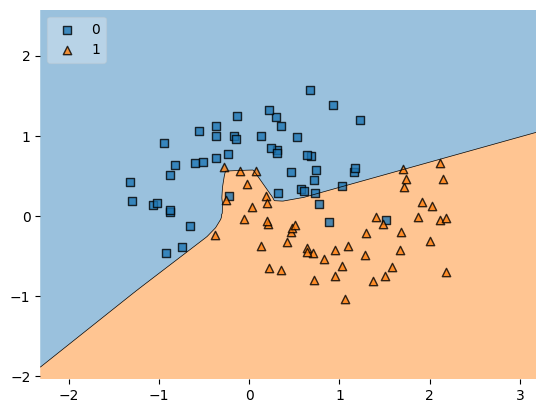

In [117]:
# Plot the decision boundary after training
plot_decision_regions(X, y.astype('int'), clf=model, legend=2)

# Xavier_Uniform and He_Uniform
- (C) Xavier_Uniform Distribution -> [-limit, +limit] where limit=sqrt(6/fan_in+fan_out), fan_in=no. of inputs in previous layer and fan_out=no.of outputs in next layer

- (d) He_Uniform Distribution -> [-limit, +limit] where limit=sqrt(6/fan_in)